# 02 — Modelo de preço/m² de terreno (EDA + treino)

Documenta o alvo, as features e a comparação **baseline × GBM × geo+zona** do modelo de preço/m² de terreno em São Paulo (ITBI público).

**Regra crítica:** o ML modela *apenas* o preço/m² (lado da receita). Viabilidade nunca é alvo de ML — é calculada (fluxo de caixa) e simulada (Monte Carlo). Validação sempre por tempo, em **walk-forward**: treina até o corte (hoje `ANO_CORTE_TREINO = 2024`, ou seja 2023+2024) e testa no ano mais novo e fechado (2025).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from loteia.model.experimento_geo import (
    montar_dataset_enriquecido, FEATURES_FINAIS_NUM, FEATURES_FINAIS_CAT,
)
from loteia.model.train import (
    split_temporal, treinar_modelo, avaliar, BaselineMedianaSetor,
    FEATURES, FEATURES_NUM, ALVO,
)
from loteia.model.explain import explicar_global

df = montar_dataset_enriquecido()
print(f'{len(df):,} terrenos limpos | anos: {sorted(map(int, df.ano.unique()))}')

3,825 terrenos limpos | anos: [2023, 2024, 2025]


/home/henryque/Documents/JOB/loteIA/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## O alvo é log-normal (cauda pesada)

Preço/m² varia de poucos reais a dezenas de milhares — a média é puxada pela cauda. Isso motivou testar log-alvo (ver seção de modelos).

count      3825.0
mean       2236.0
std        5128.0
min           4.3
1%           35.4
5%          125.0
50%        1124.6
95%        7184.1
99%       18185.2
max      121700.6


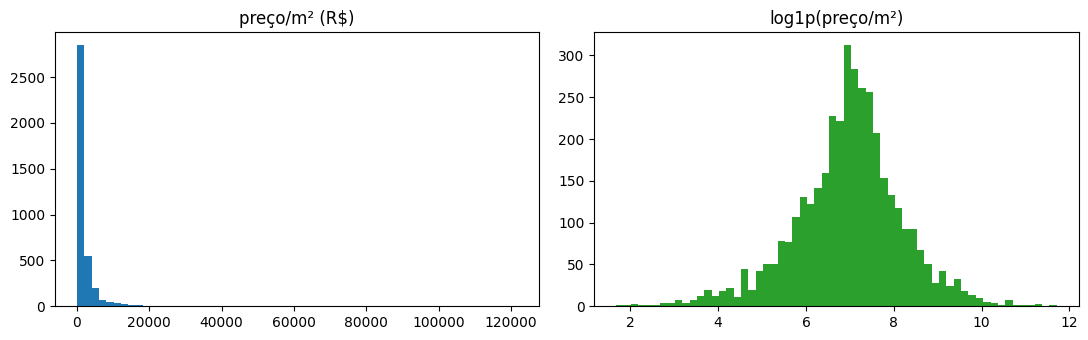

In [2]:
print(df[ALVO].describe(percentiles=[.01,.05,.5,.95,.99]).round(1).to_string())
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(df[ALVO], bins=60, color='#1f77b4'); ax[0].set_title('preço/m² (R$)')
ax[1].hist(np.log1p(df[ALVO]), bins=60, color='#2ca02c'); ax[1].set_title('log1p(preço/m²)')
fig.tight_layout()

## Features

- **Cadastrais (ITBI):** área do terreno, testada.
- **Geoespaciais (Camada 5):** x,y do centroide da quadra, distância ao centro e à estação mais próxima, comércio/escolas no raio de 1 km, renda do setor censitário (IBGE) e **zona** (zoneamento PDE 2014).

Custos (gleba, infra) **não** são features — são inputs incertos da simulação.

In [3]:
print('numéricas:', FEATURES_FINAIS_NUM)
print('categóricas:', FEATURES_FINAIS_CAT)
df[FEATURES_FINAIS_NUM].describe().round(1)

numéricas: ['area_terreno_itbi', 'testada', 'dist_centro', 'dist_estacao', 'n_comercio_1km', 'n_escola_1km', 'renda_setor', 'x', 'y']
categóricas: ['zona']


,area_terreno_itbi,testada,dist_centro,dist_estacao,n_comercio_1km,n_escola_1km,renda_setor,x,y
count,3825.0,3825.0,3820.0,3820.0,3825.0,3825.0,3786.0,3820.0,3820.0
mean,633.6,14.4,15357.5,2238.5,19.3,4.1,2602.8,334504.0,7390574.0
std,2264.7,21.0,6510.8,1708.0,51.9,3.1,3339.3,12441.5,10292.3
min,12.0,0.0,968.0,52.1,0.0,0.0,98.8,314648.3,7354194.7
25%,174.0,6.9,10666.7,984.9,1.0,2.0,949.1,323457.0,7385209.6
50%,270.0,10.0,14759.5,1788.5,4.0,4.0,1432.6,330975.7,7391530.5
75%,465.0,14.0,20084.4,3023.7,15.0,6.0,2764.8,346672.6,7398213.8
max,73301.0,553.5,42377.8,16760.2,843.0,18.0,41175.7,360504.6,7412154.8


## Split temporal e comparação de modelos

Treina com transações até o corte (2023+2024) e testa em 2025, sem embaralhar (walk-forward). Compara a baseline (mediana por setor) contra GBM de 3 features e GBM enriquecido.

In [4]:
train, test = split_temporal(df)
print(f'treino {len(train):,} (anos {sorted(map(int, train.ano.unique()))}) | '
      f'teste {len(test):,} (anos {sorted(map(int, test.ano.unique()))})')

baseline = BaselineMedianaSetor().fit(train[FEATURES], train[ALVO])
baseline.features_ = FEATURES
m_3f = treinar_modelo(train)
m_geo = treinar_modelo(train, features_num=FEATURES_FINAIS_NUM,
                       features_cat=FEATURES_FINAIS_CAT)
m_log = treinar_modelo(train, features_num=FEATURES_FINAIS_NUM,
                       features_cat=FEATURES_FINAIS_CAT, log_alvo=True)

tabela = pd.DataFrame({
    'baseline mediana/setor': avaliar(baseline, test),
    'GBM 3 features': avaliar(m_3f, test),
    'GBM geo+zona': avaliar(m_geo, test),
    'GBM geo+zona (log)': avaliar(m_log, test),
}).T.round(3)
tabela

treino 2,500 (anos [2023, 2024]) | teste 1,325 (anos [2025])


,mae,mape_mediana,r2
baseline mediana/setor,1532.620,0.422,0.222
GBM 3 features,1553.396,0.426,0.187
GBM geo+zona,1369.301,0.357,0.252
GBM geo+zona (log),1382.756,0.369,0.216


**Leitura:** o enriquecimento geoespacial reduz o MAE ~12% frente ao GBM de 3 features (1.369 vs 1.553 R$/m²) e é o **único** a superar a baseline mediana/setor (1.533) — no holdout de 2025 o GBM cru de 3 features fica até abaixo dela. Com o conjunto rico de features, o log-alvo deixou de ajudar (1.383 > 1.369) — por isso o artefato final **não** usa log. O R² ~0,25 reflete o teto de sinal de localização+área; mais anos de dados (ver notebook 03) é a alavanca de teto.

## Explicabilidade (SHAP global) — Camada 3

Importância média |SHAP| do modelo final (R$/m²): a localização domina.

dist_centro          605.3
renda_setor          266.2
n_comercio_1km       261.7
dist_estacao         248.3
y                    151.8
x                    146.5
area_terreno_itbi     79.2
zona                  71.5
testada               37.1
n_escola_1km          35.0


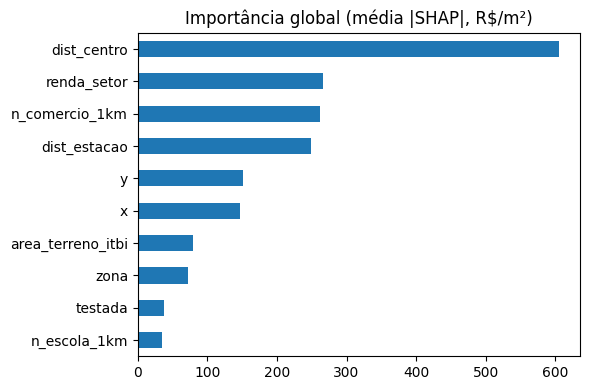

In [5]:
imp = explicar_global(m_geo, train).round(1)
print(imp.to_string())
imp.sort_values().plot.barh(figsize=(6,4), color='#1f77b4',
    title='Importância global (média |SHAP|, R$/m²)')
plt.tight_layout()

A distância ao centro, a renda do setor e as coordenadas lideram. A `zona` tem importância global baixa (a localização contínua já a captura), mas contribui localmente em terrenos específicos. Conclusão: o preço/m² é essencialmente um problema de **localização**, como esperado em terra urbana.